## Acknowledgement


The REALDISP Activity Recognition Dataset Data Set was downloaded from UC Irvine Machine Learning Repository at https://archive.ics.uci.edu/ml/datasets/REALDISP+Activity+Recognition+Dataset#

We thank to Banos at. el. providing valuable dataset. The dataset was modified and simplified for education purpose.

References:

Banos, O., Toth M. A., Damas, M., Pomares, H., Rojas, I. Dealing with the effects of sensor displacement in wearable activity recognition. Sensors vol. 14, no. 6, pp. 9995-10023 (2014). 

Banos, O., Toth, M. A., Damas, M., Pomares, H., Rojas, I., Amft, O. A benchmark dataset to evaluate sensor displacement in activity recognition. Proceedings of the 14th International Conference on Ubiquitous Computing (Ubicomp 2012), Pittsburgh, USA, September 5-8, (2012). 

code modified from: https://www.kaggle.com/pratik2901/sequential-ann-and-visualization

train.csv - the training set

test.csv - the test set

sampleSubmission.csv - a sample submission file in the correct format

**此資料包含以下欄位**

id : 資料編號

accel_body : 軀幹加速規讀數

magnet_body : 軀幹磁力計讀數

gyros_upper_limb : 上肢陀螺儀讀數

accel_upper_limb : 上肢加速規讀數

magnet_upper_limb : 上肢磁力計讀數

gyros_body : 軀幹陀螺儀讀數

gyros_lower_limb : 下肢陀螺儀讀數

accel_lower_limb : 下肢加速規讀數

magnet_lower_limb : 下肢磁力計讀數

Category : 運動類別

**感測器種類**

陀螺儀(gyroscope) : 是一種用來感測與維持方向的裝置，基於角動量守恆的理論設計出來的。

加速規 (accelerometer) : 又稱加速計、加速針、加速度傳感器、重力加速度傳感器等等，是測量加速度的裝置。

磁力計 (magnetometer) : 輔助陀螺儀，彌補重力加速度對水平角度旋轉偵測誤差。

In [1]:
# 匯入函式庫
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import optimizers

np.random.seed(3)

In [2]:
# 讀取training資料，給定變數名稱為motion
motion = pd.read_csv("../input/train.csv")

In [3]:
# 檢視training的資料大小
# 資料大小為3219列，11行的數據
print(motion.shape)

(3219, 11)


In [4]:
# 檢視motion變數內的行索引名稱
# 每一行代表不同的特徵資料
col = motion.columns # .columns gives columns names in data 
print(col)

Index(['id', 'accel_body', 'magnet_body', 'gyros_upper_limb',
       'accel_upper_limb', 'magnet_upper_limb', 'gyros_body',
       'gyros_lower_limb', 'accel_lower_limb', 'magnet_lower_limb',
       'Category'],
      dtype='object')


In [5]:
# 檢視training資料的前五列資料
# 每列代表一個sample,每行代表一種特徵資料
motion.head()  # .head gives the first 5 rows

,id,accel_body,magnet_body,gyros_upper_limb,accel_upper_limb,magnet_upper_limb,gyros_body,gyros_lower_limb,accel_lower_limb,magnet_lower_limb,Category
0,0,-109.993945,NaN,0.000004,1311.714258,very_fast,very_slow,on,on,off,0
1,1,79.967246,23.642525,93.496809,-641.751055,very_slow,very_slow,off,on,on,1
2,2,-310.995171,12.378887,0.021660,-45.945922,very_fast,slow,on,off,on,0
3,3,-246.694475,5.037199,322.111589,-412.655554,very_fast,very_slow,off,off,off,1
4,4,21.751313,21.256483,0.005549,-148.205227,fast,very_slow,off,on,on,0


In [6]:
# 檢查是否有哪行資料有遺失的數據
# 數值代表遺失的數目
# Check for missing data
motion.isnull().sum()

id                     0
accel_body             0
magnet_body          576
gyros_upper_limb       0
accel_upper_limb       0
magnet_upper_limb      0
gyros_body             0
gyros_lower_limb       0
accel_lower_limb       0
magnet_lower_limb      0
Category               0
dtype: int64

## Column #2 Missing data 的處理方式, 請看 Keras_03_Stock.ipynb

# **Visualization**


這部分透過視覺化數據，可以初步了解資料分布情形。

## Column #1 ~ #4 are numbers

畫出不同特徵，每種分類的分布情形，不同變數型態，會有不同畫法。第1~4行為數值的變數型態。（這邊不算id這行）

<Axes: xlabel='Category', ylabel='accel_body'>

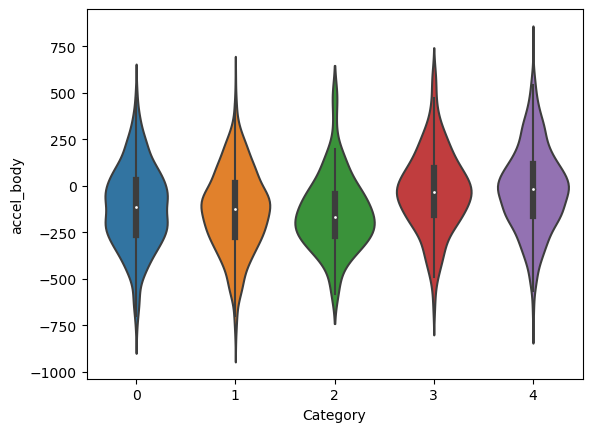

In [7]:
# 第一行(種)特徵的小提琴圖
# 橫軸是不同運動類別，縱軸為特徵的數值範圍
# Column #1
tmp = motion.accel_body
sns.violinplot(x="Category", y="accel_body", data=motion, size=6)

<Axes: xlabel='Category', ylabel='gyros_upper_limb'>

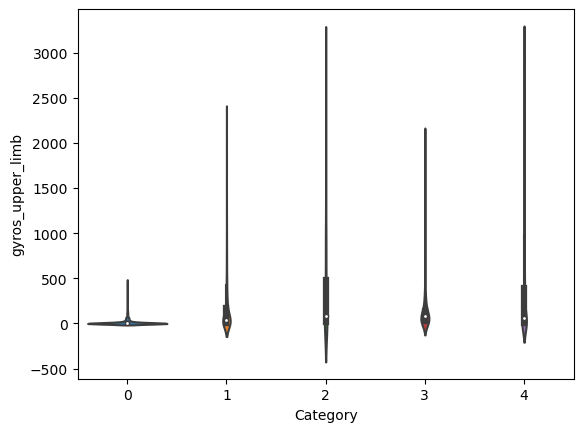

In [8]:
# 第三行特徵的小提琴圖
# Column #3
sns.violinplot(x="Category", y="gyros_upper_limb", data=motion, size=6)

<Axes: xlabel='Category', ylabel='accel_upper_limb'>

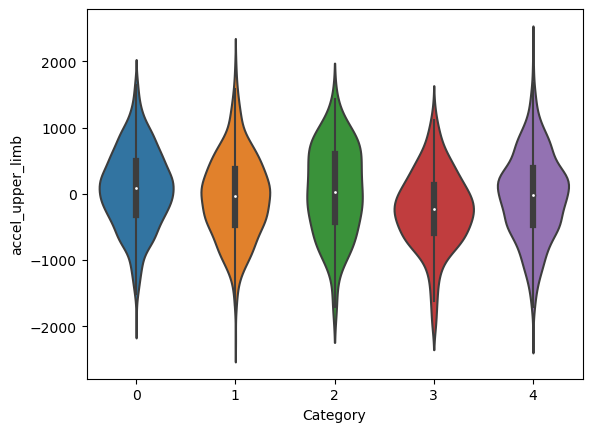

In [9]:
# 第四行特徵的小提琴圖
# Column #4
sns.violinplot(x="Category", y="accel_upper_limb", data=motion, size=6)

## Column #5 ~ #9 are text
## Change to: (A) numbers, or (B) One-Hot encoding? 

第5~9行為類別的變數型態，使用直方圖畫出檢視。類別型的變數，要經過轉換成為數字或是One-hot encoding。

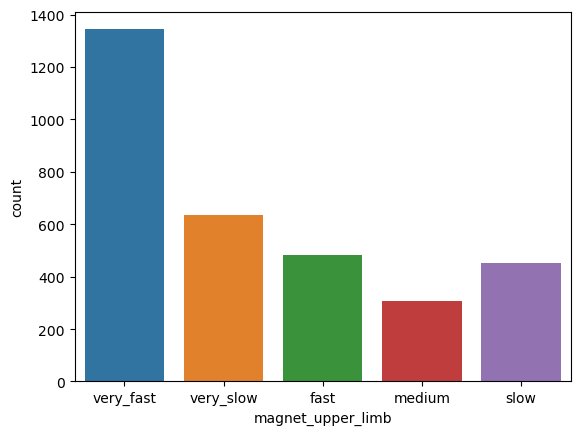

In [10]:
# 第五行特徵的直方圖
# 橫軸是特徵中不同的類別，縱軸是這個類別的總數
# [magnet_upper_limb], gyros_body, gyros_lower_limb, accel_lower_limb, magnet_lower_limb
# Column #5

ax = sns.countplot(x=motion["magnet_upper_limb"],label="Count") 

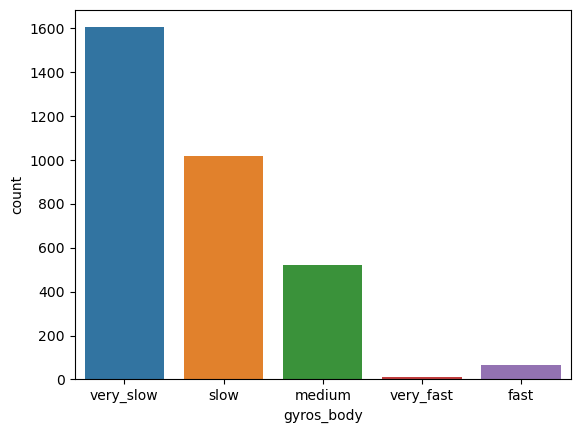

In [11]:
# 第六行特徵的直方圖
# magnet_upper_limb, [gyros_body], gyros_lower_limb, accel_lower_limb, magnet_lower_limb
# row #6
#tmp = motion.gyros_body
#ax = sns.countplot(tmp,label="Count")
ax = sns.countplot(x=motion["gyros_body"],label="Count") 

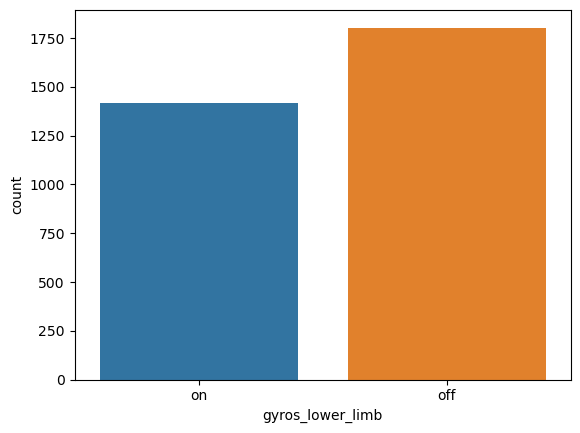

In [12]:
# 第七行特徵的直方圖
# magnet_upper_limb, gyros_body, [gyros_lower_limb], accel_lower_limb, magnet_lower_limb
# row #7
#tmp = motion.gyros_lower_limb
#ax = sns.countplot(tmp,label="Count")
ax = sns.countplot(x=motion["gyros_lower_limb"],label="Count") 

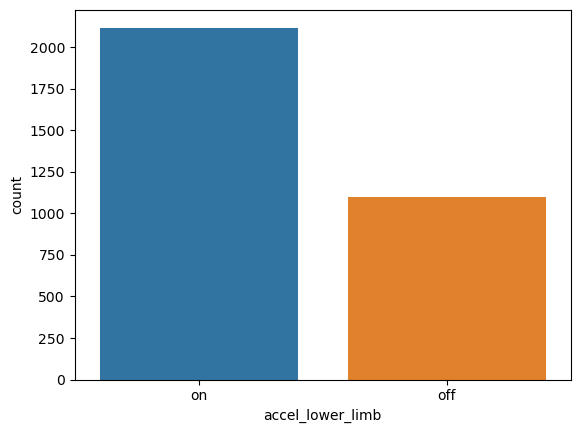

In [13]:
# 第八行特徵的直方圖
# magnet_upper_limb, gyros_body, gyros_lower_limb, [accel_lower_limb], magnet_lower_limb
# row #8
#tmp = motion.accel_lower_limb
#ax = sns.countplot(tmp,label="Count")
ax = sns.countplot(x=motion["accel_lower_limb"],label="Count") 

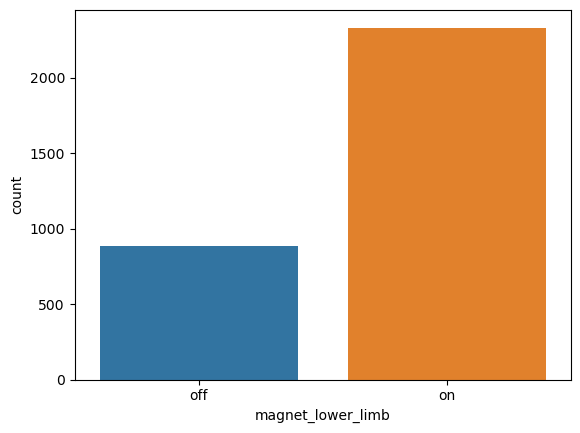

In [14]:
# 第九行特徵的直方圖
# magnet_upper_limb, gyros_body, gyros_lower_limb, accel_lower_limb, [magnet_lower_limb]
# row #9
#tmp = motion.magnet_lower_limb
#ax = sns.countplot(tmp,label="Count")
ax = sns.countplot(x=motion["magnet_lower_limb"],label="Count") 

# **Set X feature**

這邊設定丟入訓練的特徵 (X)

In [15]:
# 先使用第一、三與四行的特徵數據進行訓練，其他特徵可再加入
# use column #1, #3, #4 (numbers) for the preliminary analysis
# other rows can be added later
# 把要丟掉行名稱列成list
drop_list1 = ['id', 'magnet_body', 
        'magnet_upper_limb', 'gyros_body',
       'gyros_lower_limb', 'accel_lower_limb', 'magnet_lower_limb',
       'Category']
# 給定變數motion_1，使用.drop的function，將list內的行先丟掉，
motion_1 = motion.drop(drop_list1,axis = 1)
# 檢視motion_1的前五列數據
motion_1.head()

,accel_body,gyros_upper_limb,accel_upper_limb
0,-109.993945,0.000004,1311.714258
1,79.967246,93.496809,-641.751055
2,-310.995171,0.021660,-45.945922
3,-246.694475,322.111589,-412.655554
4,21.751313,0.005549,-148.205227


In [16]:
# 將 motion_1 轉換為float型態並指定給 X 作為訓練特徵
X = motion_1.astype(float)
# 檢視前五列數據
X.head()

,accel_body,gyros_upper_limb,accel_upper_limb
0,-109.993945,0.000004,1311.714258
1,79.967246,93.496809,-641.751055
2,-310.995171,0.021660,-45.945922
3,-246.694475,322.111589,-412.655554
4,21.751313,0.005549,-148.205227


# Set and check the distribution of Y

這邊設定每個sample的運動種類 (Category) 為 Y

0    0
1    1
2    0
3    1
4    0
Name: Category, dtype: int64


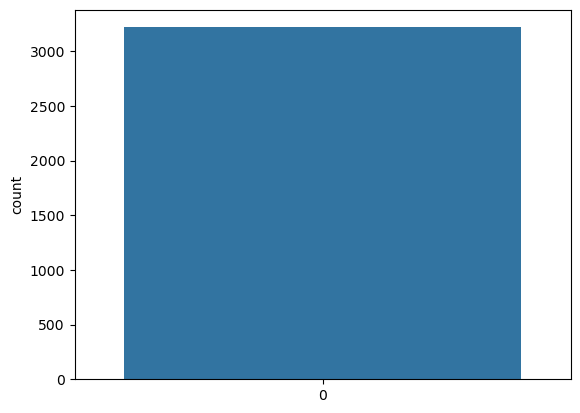

In [17]:
# 給定Y為運動種類，即為第十行 Category
# convert text into vectors
# row #10
Y = motion.Category
# 檢視前五列資料
print(Y.head())
# 畫出運動種類的直方圖，橫軸為運動種類，縱軸為類別總數
ax = sns.countplot(Y,label="Count") 

# Convert text (Y) into numbers, then One-Hot encoding

使用LabelEncoder()，使類別變數成為數字，便能進一步使用np_utils.to_categorical()，使數字變成One-hot encoding的型式。

In [18]:
# convert text into numbers
encoder = LabelEncoder()
encoder.fit(Y)
encoded_Y = encoder.transform(Y)
print(Y[0:10])
print(encoded_Y[0:10])

0    0
1    1
2    0
3    1
4    0
5    0
6    1
7    4
8    0
9    3
Name: Category, dtype: int64
[0 1 0 1 0 0 1 4 0 3]


In [19]:
# convert numbers to One-Hot encoding
answer_Y = to_categorical(encoded_Y)
print(answer_Y[0:10])

[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]]


# Try the simple "Sequential Based ANN"
## We also can try SVM, KNN, RandomForest, Gradient Boosting, etc.

建立簡單Sequential ANN的模型，並用這個模型進行訓練。另外也可建立SVM, KNN, RandomForest以及Gradient Boosting等模型進行訓練。

In [20]:
# 設定基本模型
def baseline_model():
    model = Sequential()
    model.add(Dense(8, input_dim=3, activation='relu'))
    model.add(Dense(5, activation='softmax'))
    
    model.compile(loss='categorical_crossentropy',
              optimizer='adam',metrics=['accuracy']) 
    return model

In [21]:
# 建立模型
model = baseline_model()
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 32        
                                                                 
 dense_1 (Dense)             (None, 5)                 45        
                                                                 
Total params: 77 (308.00 Byte)
Trainable params: 77 (308.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [22]:
# 開始訓練並使用cross-validation的方式進行
train_history = model.fit(X,answer_Y,validation_split=0.2,epochs=20,batch_size=5)

Epoch 1/20
515/515 [==============================] - 1s 2ms/step - loss: 82.7557 - accuracy: 0.3165 - val_loss: 28.3949 - val_accuracy: 0.3929
Epoch 2/20
515/515 [==============================] - 1s 1ms/step - loss: 20.2467 - accuracy: 0.3755 - val_loss: 9.6568 - val_accuracy: 0.4363
Epoch 3/20
515/515 [==============================] - 1s 1ms/step - loss: 8.4888 - accuracy: 0.3981 - val_loss: 4.7257 - val_accuracy: 0.4286
Epoch 4/20
515/515 [==============================] - 1s 1ms/step - loss: 4.5633 - accuracy: 0.3992 - val_loss: 3.0680 - val_accuracy: 0.3727
Epoch 5/20
515/515 [==============================] - 1s 1ms/step - loss: 2.8268 - accuracy: 0.4124 - val_loss: 2.7220 - val_accuracy: 0.4099
Epoch 6/20
515/515 [==============================] - 1s 1ms/step - loss: 2.2009 - accuracy: 0.4148 - val_loss: 1.9089 - val_accuracy: 0.3913
Epoch 7/20
515/515 [==============================] - 1s 1ms/step - loss: 1.9338 - accuracy: 0.4175 - val_loss: 1.9026 - val_accuracy: 0.4488
Epo

In [23]:
# 設定展示訓練紀錄的function
def show_train_history(train_history,train,validation):
    plt.plot(train_history.history[train])
    plt.plot(train_history.history[validation])
    plt.title('Train History')
    plt.ylabel(train)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

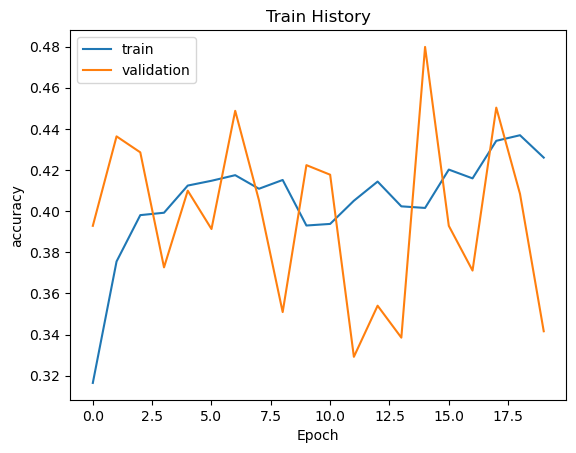

In [24]:
# 展示訓練紀錄
# 橫軸為訓練次數Epoch，縱軸為訓練準確度accuracy
show_train_history(train_history,'accuracy','val_accuracy')

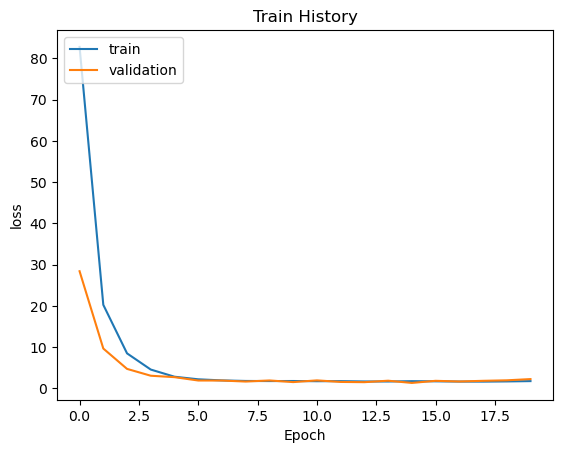

In [25]:
# 展示訓練紀錄
# 橫軸為訓練次數Epoch，縱軸為訓練Loss
show_train_history(train_history,'loss','val_loss')

In [26]:
# 計算訓練模型的最後準確度
scores = model.evaluate(X,answer_Y)
print("Accuracy:%.2f%%"%(scores[1]*100))

101/101 [==============================] - 0s 997us/step - loss: 2.2423 - accuracy: 0.3551
Accuracy:35.51%


# Confusion matrix

畫出混淆矩陣(confusion matrix)評估訓練情形。

In [27]:
# 輸入原始訓練特徵X給訓練好的模型進行預測
predict_prob = model.predict(X) 
prediction = np.argmax(predict_prob,axis=1)
print(prediction)

# 檢視訓練結果大小為3219列，因為有這麼多的sample
prediction.shape

101/101 [==============================] - 0s 771us/step
[4 1 4 ... 4 1 1]


(3219,)

In [28]:
# 展示混淆矩陣，橫軸為預測的運動種類，縱軸為實際上的運動種類
pd.crosstab(encoded_Y,prediction,
            rownames=['label'],colnames=['predict'])

predict,0,1,4
label,,,
0,284,350,458
1,109,274,338
2,7,28,54
3,21,111,89
4,142,369,585


# Generate an inference for the test data

這部分輸入test資料，不知道運動種類答案的數據，利用訓練好的模型，預測運動種類。

In [29]:
# 讀取testing的數據資料
motion_test = pd.read_csv("../input/test.csv")

In [30]:
# 檢視tesing數據資料大小
# 805列10行，表示有805個samples，以及10行是因為少了答案運動種類(Category)
print(motion_test.shape)

(805, 10)


In [31]:
# 跟前面設定X時候一樣，這邊僅利用第一、三與四行的特徵進行預測
# 因為前面也是使用這三種特徵訓練
# use column #1, #3, #4 (numbers) for the preliminary analysis
# other rows can be added later
# 丟掉的特徵list
drop_list1 = ['id', 'magnet_body', 
        'magnet_upper_limb', 'gyros_body',
       'gyros_lower_limb', 'accel_lower_limb', 'magnet_lower_limb']
# 使用.drop的function丟棄list中的行位置，並指定為變數motion_test_1
motion_test_1 = motion_test.drop(drop_list1,axis = 1)
# 檢視丟掉後的前五列數據
motion_test_1.head()

,accel_body,gyros_upper_limb,accel_upper_limb
0,-206.861063,2.040138e-01,-254.860924
1,-41.576894,1.703513e+02,384.885171
2,-52.483665,5.220289e+02,-1420.940382
3,-127.609881,5.265841e-07,1118.175947
4,-393.373979,5.848536e+01,-313.570099


In [32]:
# 將 motion_test_1 轉換為float型態並指定給 X_test 作為預測特徵
X_test = motion_test_1.astype(float)
# 檢視前五列數據
X_test.head()

,accel_body,gyros_upper_limb,accel_upper_limb
0,-206.861063,2.040138e-01,-254.860924
1,-41.576894,1.703513e+02,384.885171
2,-52.483665,5.220289e+02,-1420.940382
3,-127.609881,5.265841e-07,1118.175947
4,-393.373979,5.848536e+01,-313.570099


In [33]:
# 將 X_test 丟入模型預測，並把結果輸出成datafram，指定行索引名稱為 category
predict_prob = model.predict(X_test) 
predict_classes = np.argmax(predict_prob,axis=1)
prediction= pd.DataFrame(predict_classes,columns=['category'])

print(prediction)

# 檢視預測結果大小，805列1行
prediction.shape


26/26 [==============================] - 0s 879us/step
     category
0           1
1           4
2           1
3           4
4           1
..        ...
800         4
801         1
802         1
803         1
804         1

[805 rows x 1 columns]


(805, 1)

# Save the results to a CSV file

這部分將預設結果輸出成csv格式檔案。

In [34]:
# 創造一個只有id的dataframe
df1 = pd.DataFrame(motion_test.id)
df1.shape

(805, 1)

In [35]:
# 將id與預測答案結合在一個dataframe中
motion_test_answer = pd.concat([df1, prediction], axis=1)
# 將id這行設為列索引
motion_test_answer = motion_test_answer.set_index('id')
# 檢視前十筆數據
print(motion_test_answer[0:10])

      category
id            
3219         1
3220         4
3221         1
3222         4
3223         1
3224         1
3225         4
3226         4
3227         4
3228         4


In [36]:
# 將預測結果輸出，並取名為 answer_to_test_set
motion_test_answer.to_csv("inference_to_test_set.csv")